# Does bead background correction help or hurt stitching?

`test_bead_background_correction.ipynb` compared its 5 pipelines (`raw`,
`bg_corrected`, `ffc_corrected`, `ffc_raw_corrected`, `bgc_subtracted`) by ONE
metric: how much background-pixel noise std drops when averaging one FOV's
beads frame across rounds. That metric answers "does this reduce noise", not
the question this notebook was actually built to answer: **how does each
correction affect real cross-FOV stitching accuracy?** A correction could
reduce background noise while distorting real bead signal enough to make
overlap registration between neighbouring FOVs worse -- noise reduction and
stitching accuracy are not the same thing, and the prior notebook's
`bgc_subtracted` result (worse than doing nothing, by its own noise metric)
doesn't by itself say what happens to stitching.

Reuses `test_stitching.ipynb`'s own stitching-quality proxies directly, not a
new metric: **corner concordance** (a corner region implied by two different
4-connected neighbour registrations -- residual is how much they disagree)
and **diagonal loop closure** (a diagonal FOV registered via two independent
chained paths -- residual is how much the two paths disagree), both in um.
Same 3 independent 3x3 neighbourhoods, same `SEED`/`CENTRAL_CANDIDATE_
FRACTION`/`TOLERANCE_FRACTION` as `test_stitching.ipynb`, so this notebook's
own `raw` pipeline should reproduce that notebook's real published numbers
(epi ~0.1-0.8um, disk corner 6.2um/diagonal 10.2um mean) -- a check this
notebook is wired correctly, not just a new result.

**Beads channel only** -- the 5 correction pipelines were computed and
validated only for the bead/fiducial frame (`test_bead_background_
correction.ipynb`'s own FFC/BGC fields are bead-frame estimates); DAPI is out
of scope here.

**Reuses cached FFC/BGC fields, does not recompute them** -- `compute_
dataset_ffc_field`/`compute_dataset_bgc_field` in `test_bead_background_
correction.ipynb` already computed and cached these from every FOV of the
cells round (~500 FOVs, several minutes each); this notebook loads that same
cache (`SAMPLE_DIR/analysis/cache/test_bead_background_correction/*.npz`)
directly via `MERci.analysis.ffc.load_ffc_field` and raises a clear error if
it's missing, rather than silently re-deriving a second, possibly-different
estimate. Run `test_bead_background_correction.ipynb` first if that cache
doesn't exist yet for a dataset.

**A real, not hypothetical, risk worth watching for**: `bgc_subtracted`'s BGC
field mean was already found to be ~3x `epi`'s own representative-FOV mean
(`prompt_history/2026_09_02_2053_bgc_subtractive_model_and_display_
ranges.md`) -- subtracting it clips most of a frame, including real bead
signal, to zero. If that also happens inside this notebook's overlap-border
crops, `phase_cross_correlation` may register a near-degenerate (all-zero or
near-uniform) pair -- reported as-is (including any `nan`/suspiciously-exact-
zero residuals), not filtered out, since a correction pipeline that breaks
registration outright is itself a real answer to "how does this affect
stitching".

**Outputs**: per dataset, `SAMPLE_DIR/analysis/cache/test_stitching_bg_
correction_comparison/*.csv` (cardinal/corner/diagonal result tables, now
with a `pipeline` column) and `SAMPLE_DIR/analysis/figures/test_stitching_bg_
correction_comparison.*.png`.

## 1 — Setup

In [ ]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import shift as ndi_shift, gaussian_filter
from scipy.spatial import KDTree

MERCI_DIR = Path(os.getcwd()).parent.parent   # MERci/

sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import load_positions, read_image_frames
from MERci.common.experiment_info import load_experiment_info, resolve_sample_identity, positions_file_tag
from MERci.acquisition.configs    import get_camera_pixel_size_um, get_camera_frame_size
from MERci.acquisition.positions       import find_grid_neighbor
from MERci.acquisition.camera_rotation import (
    apply_microscope_orientation, crop_overlap, register_neighbor_pair,
)
from MERci.acquisition.alignment     import remove_hot_pixels, phase_drift
from MERci.acquisition.merlin_config import load_microscope_orientation
from MERci.analysis.ffc              import apply_ffc, load_ffc_field
from MERci.progress_display          import ProgressReporter

NOTEBOOK_NAME = "test_stitching_bg_correction_comparison"
print(f"MERCI_DIR : {MERCI_DIR}")

MERCI_DIR : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci


## 2 — Parameters

Same two real `BC555_sample_05` datasets, and the same stitching-pipeline
parameters, as `test_stitching.ipynb` -- so this notebook's own `raw`
pipeline is directly comparable to that notebook's published results.

In [ ]:
DATASETS = [
    ("epi",  "/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi"),
    ("disk", "/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk"),
]

IMAGE_SUFFIX     = ".zarr"
BEAD_FRAME_INDEX = 0   # HAL's own convention -- frame 0 of the cells round is the bead/fiducial frame.

# The 5 pipelines from test_bead_background_correction.ipynb, unchanged.
PIPELINE_NAMES = ("raw", "bg_corrected", "ffc_corrected", "ffc_raw_corrected", "bgc_subtracted")
BG_SIGMA_PX = 50.0   # local-background Gaussian-smoothing sigma -- matches that notebook's own default.

# Same neighbourhood-selection parameters as test_stitching.ipynb -- SEED=0
# reproduces that notebook's own 3 neighbourhoods exactly (same candidate
# pool, same shuffle), so this notebook's "raw" pipeline is a direct check
# against its already-published real numbers, not just a new run.
N_NEIGHBORHOODS            = 3
CENTRAL_CANDIDATE_FRACTION = 0.3
SEED                       = 0
TOLERANCE_FRACTION         = 0.25
UPSAMPLE_FACTOR             = 10

FORCE_RECOMPUTE = False

NEIGHBORHOOD_COLORS = ["tab:red", "tab:blue", "tab:green", "tab:orange", "tab:purple"]
PIPELINE_COLORS = {"raw": "0.5", "bg_corrected": "tab:blue", "ffc_corrected": "tab:green",
                    "ffc_raw_corrected": "tab:olive", "bgc_subtracted": "tab:red"}
PIPELINE_TITLES = {"raw": "raw", "bg_corrected": "local bg-corrected",
                    "ffc_corrected": "all-FOV FFC (smoothed, divide)",
                    "ffc_raw_corrected": "all-FOV FFC (raw, divide)",
                    "bgc_subtracted": "all-FOV BGC (raw, subtract)"}

PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 10

print(f"Datasets to analyze: {[label for label, _ in DATASETS]}  |  pipelines: {PIPELINE_NAMES}")

Datasets to analyze: ['epi', 'disk']  |  pipelines: ('raw', 'bg_corrected', 'ffc_corrected', 'ffc_raw_corrected', 'bgc_subtracted')


## 3 — Resolve dataset geometry

Same pattern as `test_stitching.ipynb` Section 3 (real positions-derived
step size/overlap fraction, not `ExperimentConfig`'s own formula), minus the
DAPI-specific frame-table lookups -- this notebook only ever touches the
bead frame (always index 0, HAL's own convention).

In [ ]:
def resolve_dataset_geometry(dataset_label, dataset_dir):
    sample_dir = Path(dataset_dir)
    sample_name, imaging_dir = resolve_sample_identity(sample_dir / "MERci")
    positions_tag = positions_file_tag(sample_name, imaging_dir)

    info       = load_experiment_info(sample_dir / "metadata" / "experiment_info.yaml")
    microscope = info.microscope

    config = ExperimentConfig(
        data_dir       = sample_dir / "data",
        metadata_dir   = sample_dir / "metadata",
        analysis_dir   = sample_dir / "analysis",
        settings_dir   = sample_dir / "settings",
        round_info_csv = sample_dir / "metadata" / "round_info.csv",
        positions_txt  = sample_dir / "positions" / f"positions_{positions_tag}.txt",
        image_suffix   = IMAGE_SUFFIX,
        microscope     = microscope,
    )
    meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                    image_suffix=config.image_suffix)

    def resolve_round_id(meta, imaging_type):
        for rid in meta.valid_round_ids():
            if any((s.imaging_type or "").strip().lower() == imaging_type.strip().lower()
                   for s in meta.series_for_round(rid)):
                return rid
        raise ValueError(f"No round found with imaging_type={imaging_type!r}")

    cells_round_id = resolve_round_id(meta, "cells")
    if not meta.round_fully_written(cells_round_id):
        print(f"WARNING [{dataset_label}]: cells round {cells_round_id} is not yet fully written on disk -- "
              f"some FOVs sampled below may be missing.")
    cells_series = next(s for s in meta.series_for_round(cells_round_id) if s.hal_config)

    pixel_size_um      = get_camera_pixel_size_um(microscope)
    frame_width_px, _  = get_camera_frame_size(microscope)
    frame_width_um     = frame_width_px * pixel_size_um

    full_positions = load_positions(config.positions_txt)
    cells_fov_ids  = sorted(f for f in full_positions if f in meta.fovs)

    coords_arr = np.array([full_positions[f] for f in cells_fov_ids], dtype=float)
    centroid   = coords_arr.mean(axis=0)
    nn_dist, _ = KDTree(coords_arr).query(coords_arr, k=2)
    step_size_um     = float(np.median(nn_dist[:, 1]))
    overlap_fraction = max(0.0, 1.0 - step_size_um / frame_width_um)

    print(f"[{dataset_label}] SAMPLE_DIR       : {sample_dir}")
    print(f"[{dataset_label}] MICROSCOPE       : {microscope}")
    print(f"[{dataset_label}] Cells round      : {cells_round_id}")
    print(f"[{dataset_label}] Step size (um)   : {step_size_um:.3f}  |  Overlap fraction: {overlap_fraction:.3f}")
    print(f"[{dataset_label}] FOVs (cells round): {len(cells_fov_ids)}")

    figures_dir = config.analysis_dir / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    return {
        "dataset_label": dataset_label, "sample_dir": sample_dir, "sample_name": sample_name,
        "microscope": microscope, "config": config, "meta": meta,
        "cells_round_id": cells_round_id, "cells_series": cells_series,
        "pixel_size_um": pixel_size_um, "frame_width_um": frame_width_um,
        "full_positions": full_positions, "cells_fov_ids": cells_fov_ids,
        "coords_arr": coords_arr, "centroid": centroid,
        "step_size_um": step_size_um, "overlap_fraction": overlap_fraction,
        "figures_dir": figures_dir,
    }

## 4 — The 5 correction pipelines + oriented frame loader

`subtract_local_background`/`subtract_bgc` copied verbatim from
`test_bead_background_correction.ipynb` Section 6 (see that notebook for the
rationale). Correction is applied in RAW camera-pixel orientation -- the same
space the cached FFC/BGC fields were computed in -- then `apply_microscope_
orientation` converts to physical stage row=y/col=x orientation, exactly like
`test_stitching.ipynb`'s own `make_frame_loader`. Corrections are pixel-wise,
so this order is equivalent to orienting first and correcting second; doing
it in this order avoids re-deriving an oriented copy of each field.

One raw read per FOV (kept in memory, cheap: `uint16`), reused for all 5
pipelines' correction+orientation on demand -- avoids 5x disk reads without
holding all 5 pipelines' corrected `float` copies of every FOV in memory at
once (this notebook runs inside a memory-capped interactive SLURM job; 5
pipelines x 27 FOVs of `float32` corrected frames is ~2.9GB and OOM-killed
the kernel in an earlier run -- see Section 7's own comment for the fix).

In [ ]:
def subtract_local_background(frame, sigma_px=BG_SIGMA_PX):
    """Ported from test_bead_background_correction.ipynb Section 6."""
    bg = gaussian_filter(frame.astype(float), sigma=sigma_px)
    return frame.astype(float) - bg + bg.mean()


def subtract_bgc(frame, bgc_field):
    """Ported from test_bead_background_correction.ipynb Section 6."""
    return np.clip(frame.astype(np.float32) - bgc_field, 0, None)


def load_dataset_bg_fields(dataset_geo):
    """Loads the FFC (smoothed + raw) and BGC fields test_bead_background_
    correction.ipynb already computed and cached for this dataset -- does
    NOT recompute them (see Cell 0's intro)."""
    label = dataset_geo["dataset_label"]
    cache_dir = dataset_geo["config"].analysis_dir / "cache" / "test_bead_background_correction"
    paths = {"ffc_corrected": cache_dir / "ffc_field.npz",
             "ffc_raw_corrected": cache_dir / "ffc_field_raw.npz",
             "bgc_subtracted": cache_dir / "bgc_field.npz"}
    missing = {name: p for name, p in paths.items() if not p.exists()}
    if missing:
        raise FileNotFoundError(
            f"[{label}] Missing cached background-correction field(s): {missing}. "
            f"Run notebooks/tests/test_bead_background_correction.ipynb for this dataset first.")
    ffc_field,     _ = load_ffc_field(paths["ffc_corrected"])
    ffc_field_raw, _ = load_ffc_field(paths["ffc_raw_corrected"])
    bgc_field,     _ = load_ffc_field(paths["bgc_subtracted"])
    print(f"[{label}] Loaded cached fields: {list(paths.values())}")
    return ffc_field, ffc_field_raw, bgc_field


def make_pipeline_frame_loader(dataset_geo, ffc_field, ffc_field_raw, bgc_field):
    orientation = load_microscope_orientation(dataset_geo["microscope"],
                                               MERCI_DIR / "data" / "configs" / "merlin" / "microscope")
    transpose       = bool(orientation.get("transpose", False))
    flip_horizontal = bool(orientation.get("flip_horizontal", False))
    flip_vertical   = bool(orientation.get("flip_vertical", False))
    print(f"[{dataset_geo['dataset_label']}] transpose={transpose}  "
          f"flip_horizontal={flip_horizontal}  flip_vertical={flip_vertical}")

    cells_series, config = dataset_geo["cells_series"], dataset_geo["config"]
    correction_fns = {
        "raw":               lambda f: f.astype(float),
        "bg_corrected":      subtract_local_background,
        "ffc_corrected":     lambda f: apply_ffc(f, ffc_field),
        "ffc_raw_corrected": lambda f: apply_ffc(f, ffc_field_raw),
        "bgc_subtracted":    lambda f: subtract_bgc(f, bgc_field),
    }

    def load_raw_frame(fov_id):
        """One raw (uint16, unoriented, uncorrected) read for *fov_id*."""
        path = cells_series.resolve_path(fov_id, config.image_suffix)
        return read_image_frames(path, [BEAD_FRAME_INDEX],
                                  frame_width=config.frame_width, frame_height=config.frame_height)[0]

    def apply_pipeline(raw_frame, pipeline_name):
        """Correction (raw camera-pixel space) then orientation, for one already-read raw frame."""
        return apply_microscope_orientation(correction_fns[pipeline_name](raw_frame),
                                             transpose, flip_horizontal, flip_vertical)

    return load_raw_frame, apply_pipeline

## 5 — Find 3 independent 3x3 neighbourhoods

Ported unchanged from `test_stitching.ipynb` Section 5.

In [ ]:
def find_3x3_block(fov_ids, positions, step_size_um, tolerance_fraction):
    def _diag(fov_a, dir_from_a, fov_b, dir_from_b):
        d = find_grid_neighbor(fov_a, positions, dir_from_a, step_size_um, tolerance_fraction)
        if d is None:
            d = find_grid_neighbor(fov_b, positions, dir_from_b, step_size_um, tolerance_fraction)
        return d

    for center in fov_ids:
        up    = find_grid_neighbor(center, positions, "up",    step_size_um, tolerance_fraction)
        down  = find_grid_neighbor(center, positions, "down",  step_size_um, tolerance_fraction)
        left  = find_grid_neighbor(center, positions, "left",  step_size_um, tolerance_fraction)
        right = find_grid_neighbor(center, positions, "right", step_size_um, tolerance_fraction)
        if None in (up, down, left, right):
            continue
        up_left    = _diag(up, "left", left, "up")
        up_right   = _diag(up, "right", right, "up")
        down_left  = _diag(down, "left", left, "down")
        down_right = _diag(down, "right", right, "down")
        if None in (up_left, up_right, down_left, down_right):
            continue
        return {
            "center": center, "up": up, "down": down, "left": left, "right": right,
            "up_left": up_left, "up_right": up_right,
            "down_left": down_left, "down_right": down_right,
        }
    return None


def find_neighborhoods(dataset_geo):
    dataset_label  = dataset_geo["dataset_label"]
    cells_fov_ids  = dataset_geo["cells_fov_ids"]
    coords_arr     = dataset_geo["coords_arr"]
    centroid       = dataset_geo["centroid"]
    full_positions = dataset_geo["full_positions"]
    step_size_um   = dataset_geo["step_size_um"]

    dist_to_centroid = np.hypot(coords_arr[:, 0] - centroid[0], coords_arr[:, 1] - centroid[1])
    order = np.argsort(dist_to_centroid)
    n_candidates = max(N_NEIGHBORHOODS * 9, int(round(len(cells_fov_ids) * CENTRAL_CANDIDATE_FRACTION)))
    central_candidates = [cells_fov_ids[i] for i in order[:n_candidates]]

    rng = np.random.default_rng(SEED)
    shuffled = list(central_candidates)
    rng.shuffle(shuffled)

    used_fovs = set()
    neighborhoods = []
    for candidate in shuffled:
        if candidate in used_fovs:
            continue
        block = find_3x3_block([candidate], full_positions, step_size_um, TOLERANCE_FRACTION)
        if block is None:
            continue
        block_fovs = set(block.values())
        if block_fovs & used_fovs:
            continue
        neighborhoods.append(block)
        used_fovs |= block_fovs
        if len(neighborhoods) == N_NEIGHBORHOODS:
            break

    if len(neighborhoods) < N_NEIGHBORHOODS:
        raise RuntimeError(
            f"[{dataset_label}] Only found {len(neighborhoods)}/{N_NEIGHBORHOODS} independent 3x3 "
            f"neighbourhoods near the tissue centroid -- try raising CENTRAL_CANDIDATE_FRACTION.")

    for i, block in enumerate(neighborhoods):
        print(f"[{dataset_label}] Neighbourhood {i}: center={block['center']}  {block}")

    return neighborhoods

## 6 — Registration helpers

Ported from `test_stitching.ipynb` Section 6, with the `channel` dict layer
removed -- `frames` here maps `fov_id -> one 2-D image` (one pipeline's own
corrected+oriented bead frame), not `fov_id -> {"beads": ..., "dapi": ...}`,
since this notebook loops over pipelines rather than channels.

In [ ]:
CORNER_DIRS = {
    "up_left":    ("up", "left"),
    "up_right":   ("up", "right"),
    "down_left":  ("down", "left"),
    "down_right": ("down", "right"),
}
DIAGONAL_CHAIN = {
    "up_left":    (("up", "left"), ("left", "up")),
    "up_right":   (("up", "right"), ("right", "up")),
    "down_left":  (("down", "left"), ("left", "down")),
    "down_right": (("down", "right"), ("right", "down")),
}


def register_cardinal(block, frames, full_positions, overlap_fraction, pixel_size_um):
    center_img = frames[block["center"]]
    out = {}
    for direction in ("up", "down", "left", "right"):
        nb_fov = block[direction]
        nb_img = frames[nb_fov]
        measured_xy, error = register_neighbor_pair(
            center_img, nb_img, full_positions[block["center"]], full_positions[nb_fov],
            direction, overlap_fraction, pixel_size_um, UPSAMPLE_FACTOR,
        )
        out[direction] = {
            "neighbor_fov": nb_fov, "nominal_xy": full_positions[nb_fov],
            "measured_xy": measured_xy, "error": error,
        }
    return out


def _pixel_shift_from_measured(measured_xy, nominal_xy, pixel_size_um):
    dx_px = (measured_xy[0] - nominal_xy[0]) / pixel_size_um
    dy_px = (measured_xy[1] - nominal_xy[1]) / pixel_size_um
    return dy_px, dx_px


def corner_check(block, frames, cardinal_results, corner_name, overlap_fraction, pixel_size_um):
    dir1, dir2 = CORNER_DIRS[corner_name]
    center_img = frames[block["center"]]
    img1, img2 = frames[block[dir1]], frames[block[dir2]]

    a1, n1 = crop_overlap(center_img, img1, dir1, overlap_fraction)
    a2, n2 = crop_overlap(center_img, img2, dir2, overlap_fraction)
    N = a1.shape[0]

    dy1, dx1 = _pixel_shift_from_measured(cardinal_results[dir1]["measured_xy"], cardinal_results[dir1]["nominal_xy"], pixel_size_um)
    dy2, dx2 = _pixel_shift_from_measured(cardinal_results[dir2]["measured_xy"], cardinal_results[dir2]["nominal_xy"], pixel_size_um)
    aligned1 = ndi_shift(n1.astype(float), shift=(dy1, dx1), order=1, mode="nearest")
    aligned2 = ndi_shift(n2.astype(float), shift=(dy2, dx2), order=1, mode="nearest")

    col_slice = slice(0, N) if dir2 == "left"  else slice(-N, None)
    row_slice = slice(-N, None) if dir1 == "up" else slice(0, N)

    center_corner   = a1[:, col_slice]
    corner_from_dir1 = aligned1[:, col_slice]
    corner_from_dir2 = aligned2[row_slice, :]

    consistency_check = float(np.max(np.abs(center_corner.astype(float) - a2[row_slice, :].astype(float))))

    shift_px, err = phase_drift(remove_hot_pixels(corner_from_dir1), remove_hot_pixels(corner_from_dir2), UPSAMPLE_FACTOR)
    residual_um = float(np.hypot(*shift_px) * pixel_size_um)

    return {
        "residual_um": residual_um, "registration_error": err,
        "center_slice_consistency_maxdiff": consistency_check,
    }


def register_chained(anchor_measured_xy, anchor_nominal_xy, anchor_img, target_img, target_nominal_xy, direction,
                      overlap_fraction, pixel_size_um):
    raw_measured_xy, error = register_neighbor_pair(
        anchor_img, target_img, anchor_nominal_xy, target_nominal_xy,
        direction, overlap_fraction, pixel_size_um, UPSAMPLE_FACTOR,
    )
    relative_offset = (raw_measured_xy[0] - anchor_nominal_xy[0], raw_measured_xy[1] - anchor_nominal_xy[1])
    chained_xy = (anchor_measured_xy[0] + relative_offset[0], anchor_measured_xy[1] + relative_offset[1])
    return chained_xy, error


def diagonal_loop_closure(block, frames, cardinal_results, corner_name, full_positions,
                           overlap_fraction, pixel_size_um):
    (anchor1_key, dir1), (anchor2_key, dir2) = DIAGONAL_CHAIN[corner_name]
    diag_fov = block[corner_name]
    diag_img = frames[diag_fov]

    anchor1_fov, anchor2_fov = block[anchor1_key], block[anchor2_key]
    via1_xy, err1 = register_chained(
        cardinal_results[anchor1_key]["measured_xy"], full_positions[anchor1_fov],
        frames[anchor1_fov], diag_img, full_positions[diag_fov], dir1,
        overlap_fraction, pixel_size_um,
    )
    via2_xy, err2 = register_chained(
        cardinal_results[anchor2_key]["measured_xy"], full_positions[anchor2_fov],
        frames[anchor2_fov], diag_img, full_positions[diag_fov], dir2,
        overlap_fraction, pixel_size_um,
    )
    residual_um = float(np.hypot(via1_xy[0] - via2_xy[0], via1_xy[1] - via2_xy[1]))
    return {
        "diag_fov": diag_fov, "anchor1_key": anchor1_key, "anchor2_key": anchor2_key,
        "via1_xy": via1_xy, "via2_xy": via2_xy, "error1": err1, "error2": err2,
        "residual_um": residual_um,
    }

## 7 — Run all 5 pipelines x 3 neighbourhoods, per dataset (cached)

Same 3 neighbourhoods are reused across all 5 pipelines (found once per
dataset, before the pipeline loop), so every pipeline's residuals come from
the identical FOVs/corners/diagonals -- a fair, paired comparison, not 5
independently-sampled neighbourhoods.

**Memory**: only the 27 raw (`uint16`) frames are kept for the whole run;
each pipeline's corrected+oriented (`float32`) copies are built one 3x3
block at a time (9 FOVs) and discarded before the next block/pipeline --
peak ~9 x 21MB instead of 5 x 27 x 21MB. An earlier version materialized all
5 pipelines x 27 FOVs at once (~2.9GB) and got OOM-killed by this
notebook's memory-capped interactive SLURM job partway through `disk`.

In [ ]:
RESULTS = {}

for dataset_label, dataset_dir in DATASETS:
    print(f"\n=== {dataset_label} ({dataset_dir}) ===")
    dataset_geo = resolve_dataset_geometry(dataset_label, dataset_dir)
    ffc_field, ffc_field_raw, bgc_field = load_dataset_bg_fields(dataset_geo)
    load_raw_frame, apply_pipeline = make_pipeline_frame_loader(dataset_geo, ffc_field, ffc_field_raw, bgc_field)
    neighborhoods = find_neighborhoods(dataset_geo)

    full_positions   = dataset_geo["full_positions"]
    overlap_fraction = dataset_geo["overlap_fraction"]
    pixel_size_um    = dataset_geo["pixel_size_um"]
    config           = dataset_geo["config"]

    CACHE_DIR = config.analysis_dir / "cache" / NOTEBOOK_NAME
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cardinal_csv = CACHE_DIR / "cardinal_results.csv"
    corner_csv   = CACHE_DIR / "corner_results.csv"
    diagonal_csv = CACHE_DIR / "diagonal_results.csv"

    if not FORCE_RECOMPUTE and cardinal_csv.exists() and corner_csv.exists() and diagonal_csv.exists():
        cardinal_df = pd.read_csv(cardinal_csv)
        corner_df   = pd.read_csv(corner_csv)
        diagonal_df = pd.read_csv(diagonal_csv)
        print(f"[{dataset_label}] Loaded cached results from {CACHE_DIR}")
    else:
        cardinal_rows, corner_rows, diagonal_rows = [], [], []

        reporter = ProgressReporter(total=len(neighborhoods) * 9, label=f"[{dataset_label}] Loading raw FOV frames")
        raw_frames = {}   # {fov_id: raw uint16 frame} -- all 27, kept for the whole run (cheap).
        for block in neighborhoods:
            for fov_id in sorted(set(block.values())):
                raw_frames[fov_id] = load_raw_frame(fov_id)
                reporter.update(1)
        reporter.done()

        for i, block in enumerate(neighborhoods):
            for pipeline_name in PIPELINE_NAMES:
                # This block's 9 corrected+oriented frames only -- built here, discarded after this
                # pipeline's registration below (see Section 7's own memory note).
                frames = {fov_id: apply_pipeline(raw_frames[fov_id], pipeline_name)
                          for fov_id in set(block.values())}
                cardinal_results = register_cardinal(block, frames, full_positions, overlap_fraction, pixel_size_um)
                for direction, r in cardinal_results.items():
                    cardinal_rows.append({
                        "neighborhood": i, "pipeline": pipeline_name, "direction": direction,
                        "center_fov": block["center"], "neighbor_fov": r["neighbor_fov"],
                        "nominal_x": r["nominal_xy"][0], "nominal_y": r["nominal_xy"][1],
                        "measured_x": r["measured_xy"][0], "measured_y": r["measured_xy"][1],
                        "shift_um": float(np.hypot(r["measured_xy"][0] - r["nominal_xy"][0],
                                                    r["measured_xy"][1] - r["nominal_xy"][1])),
                        "error": r["error"],
                    })

                for corner_name in CORNER_DIRS:
                    cc = corner_check(block, frames, cardinal_results, corner_name, overlap_fraction, pixel_size_um)
                    corner_rows.append({
                        "neighborhood": i, "pipeline": pipeline_name, "corner": corner_name,
                        "center_fov": block["center"],
                        "residual_um": cc["residual_um"], "registration_error": cc["registration_error"],
                        "center_slice_consistency_maxdiff": cc["center_slice_consistency_maxdiff"],
                    })

                for corner_name in DIAGONAL_CHAIN:
                    dc = diagonal_loop_closure(block, frames, cardinal_results, corner_name,
                                                full_positions, overlap_fraction, pixel_size_um)
                    diagonal_rows.append({
                        "neighborhood": i, "pipeline": pipeline_name, "corner": corner_name,
                        "diag_fov": dc["diag_fov"], "anchor1_key": dc["anchor1_key"], "anchor2_key": dc["anchor2_key"],
                        "error1": dc["error1"], "error2": dc["error2"],
                        "residual_um": dc["residual_um"],
                    })

        cardinal_df = pd.DataFrame(cardinal_rows)
        corner_df   = pd.DataFrame(corner_rows)
        diagonal_df = pd.DataFrame(diagonal_rows)
        cardinal_df.to_csv(cardinal_csv, index=False)
        corner_df.to_csv(corner_csv, index=False)
        diagonal_df.to_csv(diagonal_csv, index=False)
        print(f"[{dataset_label}] Saved: {cardinal_csv}, {corner_csv}, {diagonal_csv}")

    cardinal_df["dataset"] = dataset_label
    corner_df["dataset"]   = dataset_label
    diagonal_df["dataset"] = dataset_label

    print(f"[{dataset_label}] cardinal_df: {len(cardinal_df)} rows, corner_df: {len(corner_df)} rows, "
          f"diagonal_df: {len(diagonal_df)} rows")

    RESULTS[dataset_label] = {
        "dataset_geo": dataset_geo, "figures_dir": dataset_geo["figures_dir"],
        "sample_name": dataset_geo["sample_name"], "neighborhoods": neighborhoods,
        "cardinal_df": cardinal_df, "corner_df": corner_df, "diagonal_df": diagonal_df,
    }

print(f"\nDatasets analyzed: {list(RESULTS.keys())}")


=== epi (/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi) ===


[epi] SAMPLE_DIR       : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi
[epi] MICROSCOPE       : MF3
[epi] Cells round      : 1
[epi] Step size (um)   : 199.066  |  Overlap fraction: 0.100
[epi] FOVs (cells round): 476


[epi] Loaded cached fields: [PosixPath('/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_bead_background_correction/ffc_field.npz'), PosixPath('/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_bead_background_correction/ffc_field_raw.npz'), PosixPath('/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_bead_background_correction/bgc_field.npz')]
[epi] transpose=True  flip_horizontal=False  flip_vertical=True
[epi] Neighbourhood 0: center=293  {'center': 293, 'up': 294, 'down': 292, 'left': 276, 'right': 310, 'up_left': 275, 'up_right': 309, 'down_left': 277, 'down_right': 311}
[epi] Neighbourhood 1: center=171  {'center': 171, 'up': 170, 'down': 172, 'left': 151, 'right': 184, 'up_left': 152, 'up_right': 185, 'down_left': 150, 'down_right': 183}
[epi] Neighbourhood 2: center=154  {'center': 154

[disk] SAMPLE_DIR       : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk
[disk] MICROSCOPE       : ST2
[disk] Cells round      : 1
[disk] Step size (um)   : 182.062  |  Overlap fraction: 0.100
[disk] FOVs (cells round): 603


[disk] Loaded cached fields: [PosixPath('/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_bead_background_correction/ffc_field.npz'), PosixPath('/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_bead_background_correction/ffc_field_raw.npz'), PosixPath('/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_bead_background_correction/bgc_field.npz')]
[disk] transpose=True  flip_horizontal=True  flip_vertical=False
[disk] Neighbourhood 0: center=177  {'center': 177, 'up': 176, 'down': 178, 'left': 155, 'right': 199, 'up_left': 156, 'up_right': 200, 'down_left': 154, 'down_right': 198}
[disk] Neighbourhood 1: center=196  {'center': 196, 'up': 197, 'down': 195, 'left': 180, 'right': 225, 'up_left': 179, 'up_right': 224, 'down_left': 181, 'down_right': 226}
[disk] Neighbourhood 2: center=326  {'cent

...

[disk] Loading raw FOV frames: [############------------] 14/27 ( 51.9%)  elapsed 1s  ETA 1s          

[disk] Loading raw FOV frames: [#################-------] 20/27 ( 74.1%)  elapsed 2s  ETA 1s          

[disk] Loading raw FOV frames: [########################] 27/27 (100.0%)  elapsed 2s  ETA 0s          

[disk] Loading raw FOV frames: [########################] 27/27 (100.0%)  elapsed 2s  ETA 0s          

[disk] Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_stitching_bg_correction_comparison/cardinal_results.csv, /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_stitching_bg_correction_comparison/corner_results.csv, /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_stitching_bg_correction_comparison/diagonal_results.csv
[disk] cardinal_df: 60 rows, corner_df: 60 rows, diagonal_df: 60 rows

Datasets analyzed: ['epi', 'disk']


## 8 — Sanity check: does `raw` reproduce `test_stitching.ipynb`'s own numbers?

Same neighbourhoods (`SEED=0`), same registration code -- this pipeline's
`raw` corner/diagonal residuals should land close to that notebook's own
published means (epi corner/diagonal ~0.1-0.8um; disk corner ~6.2um,
diagonal ~10.2um). A large disagreement would mean something in this
notebook's own port is wrong, not a new finding about `raw`.

In [ ]:
for dataset_label, R in RESULTS.items():
    raw_corner   = R["corner_df"][R["corner_df"].pipeline == "raw"]["residual_um"]
    raw_diagonal = R["diagonal_df"][R["diagonal_df"].pipeline == "raw"]["residual_um"]
    print(f"[{dataset_label}] raw corner residual_um  : mean={raw_corner.mean():.3f}  median={raw_corner.median():.3f}")
    print(f"[{dataset_label}] raw diagonal residual_um: mean={raw_diagonal.mean():.3f}  median={raw_diagonal.median():.3f}")

[epi] raw corner residual_um  : mean=0.766  median=0.380
[epi] raw diagonal residual_um: mean=0.063  median=0.063
[disk] raw corner residual_um  : mean=7.561  median=8.901
[disk] raw diagonal residual_um: mean=10.150  median=11.220


## 9 — Corner concordance across all 5 pipelines

Per dataset: mean +/- std corner residual per pipeline (bar), with every
individual neighbourhood x corner data point overlaid (12 points/pipeline:
3 neighbourhoods x 4 corners) so a single outlier isn't hidden inside the
mean.

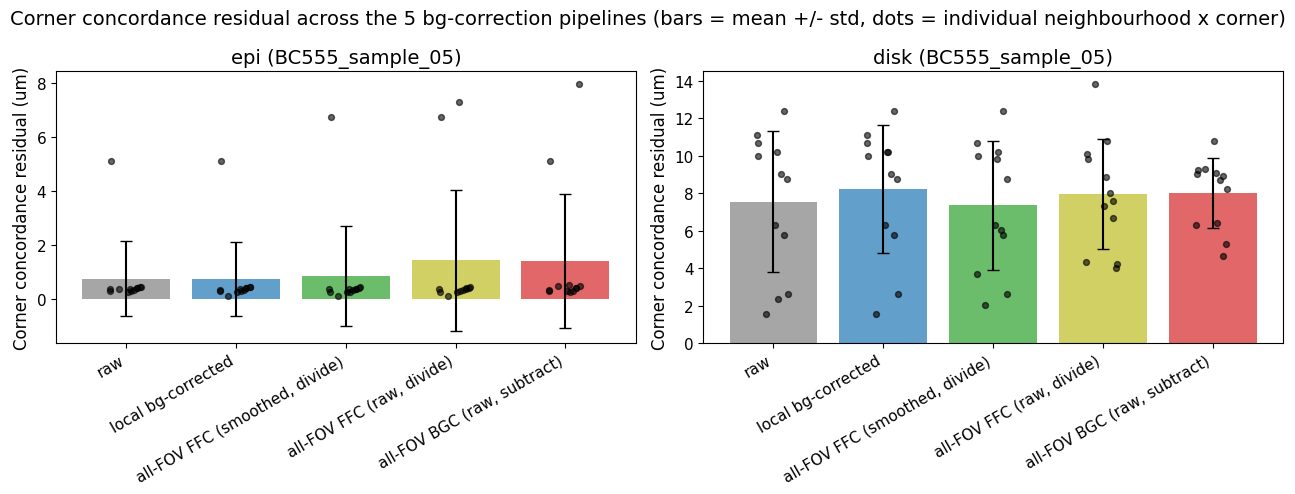

Saved: /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/test_stitching_bg_correction_comparison/test_stitching_bg_correction_comparison.corner_comparison.png


In [ ]:
def plot_residual_comparison(results, df_key, title_metric, fig_suffix):
    fig, axes = plt.subplots(1, len(results), figsize=(6.5 * len(results), 5), squeeze=False)
    for col, (dataset_label, R) in enumerate(results.items()):
        ax = axes[0, col]
        df = R[df_key]
        means = [df[df.pipeline == p]["residual_um"].mean() for p in PIPELINE_NAMES]
        stds  = [df[df.pipeline == p]["residual_um"].std()  for p in PIPELINE_NAMES]
        x = np.arange(len(PIPELINE_NAMES))
        ax.bar(x, means, yerr=stds, capsize=4,
               color=[PIPELINE_COLORS[p] for p in PIPELINE_NAMES], alpha=0.7)
        for i, p in enumerate(PIPELINE_NAMES):
            vals = df[df.pipeline == p]["residual_um"].values
            jitter = (np.random.default_rng(0).random(len(vals)) - 0.5) * 0.3
            ax.scatter(np.full(len(vals), i) + jitter, vals, color="k", s=18, zorder=3, alpha=0.6)
        ax.set_xticks(x)
        ax.set_xticklabels([PIPELINE_TITLES[p] for p in PIPELINE_NAMES], rotation=30, ha="right",
                            fontsize=PLOT_TICK_FONTSIZE)
        ax.set_ylabel(f"{title_metric} residual (um)", fontsize=PLOT_LABEL_FONTSIZE)
        ax.set_title(f"{dataset_label} ({R['sample_name']})", fontsize=PLOT_TITLE_FONTSIZE)
        ax.tick_params(axis="y", labelsize=PLOT_TICK_FONTSIZE)
    fig.suptitle(f"{title_metric} residual across the 5 bg-correction pipelines "
                 f"(bars = mean +/- std, dots = individual neighbourhood x corner)",
                 fontsize=PLOT_TITLE_FONTSIZE)
    fig.tight_layout()
    fig_path = MERCI_DIR / "cache" / "test_stitching_bg_correction_comparison" / f"{NOTEBOOK_NAME}.{fig_suffix}.png"
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(fig_path, dpi=150)
    plt.show()
    print(f"Saved: {fig_path}")


plot_residual_comparison(RESULTS, "corner_df", "Corner concordance", "corner_comparison")

## 10 — Diagonal loop closure across all 5 pipelines

Same layout as Section 9 -- the more demanding, chained-registration check
(`test_stitching.ipynb`'s own real result found this the one where beads
clearly beat DAPI on `disk`, unlike corner concordance).

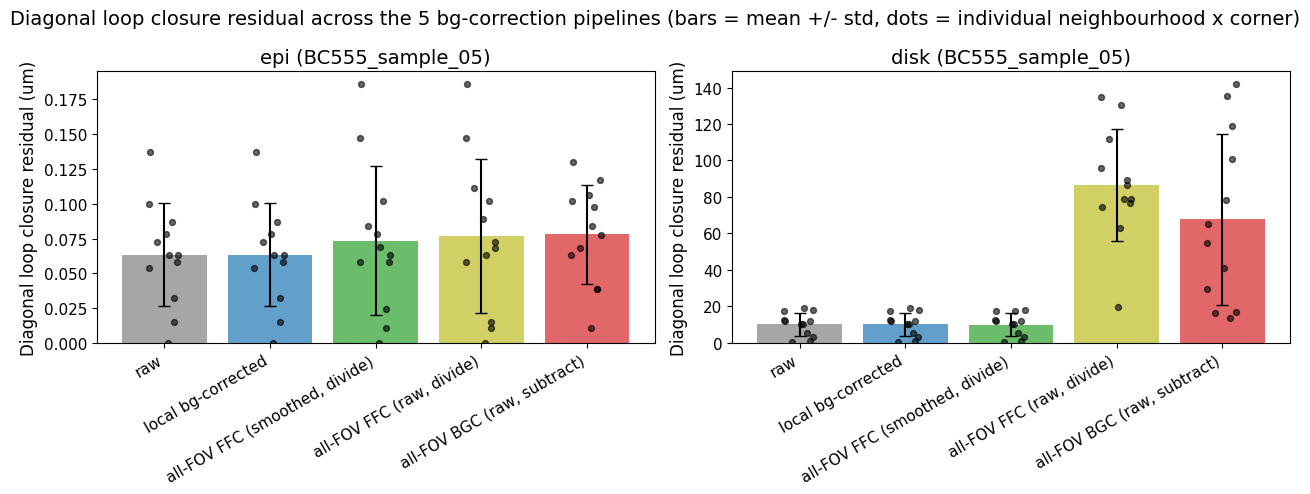

Saved: /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/test_stitching_bg_correction_comparison/test_stitching_bg_correction_comparison.diagonal_comparison.png


In [ ]:
plot_residual_comparison(RESULTS, "diagonal_df", "Diagonal loop closure", "diagonal_comparison")

## 11 — Summary table

The direct answer to "how does each correction affect stitching, not just
noise": mean/median corner and diagonal residual_um per pipeline per
dataset, plus how many individual registrations came back `nan` (a
correction that broke registration outright, e.g. `bgc_subtracted` clipping
most of a frame to zero -- see Cell 0's intro).

In [ ]:
summary_rows = []
for dataset_label, R in RESULTS.items():
    for pipeline_name in PIPELINE_NAMES:
        corner_vals   = R["corner_df"][R["corner_df"].pipeline == pipeline_name]["residual_um"]
        diagonal_vals = R["diagonal_df"][R["diagonal_df"].pipeline == pipeline_name]["residual_um"]
        summary_rows.append({
            "dataset": dataset_label, "pipeline": pipeline_name,
            "corner_mean_um": corner_vals.mean(), "corner_median_um": corner_vals.median(),
            "corner_n_nan": int(corner_vals.isna().sum()),
            "diagonal_mean_um": diagonal_vals.mean(), "diagonal_median_um": diagonal_vals.median(),
            "diagonal_n_nan": int(diagonal_vals.isna().sum()),
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.round(3).to_string(index=False))

summary_csv = MERCI_DIR / "cache" / "test_stitching_bg_correction_comparison" / f"{NOTEBOOK_NAME}.summary.csv"
summary_csv.parent.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(summary_csv, index=False)
print(f"Saved: {summary_csv}")

dataset          pipeline  corner_mean_um  corner_median_um  corner_n_nan  diagonal_mean_um  diagonal_median_um  diagonal_n_nan
    epi               raw           0.766             0.380             0             0.063               0.063               0
    epi      bg_corrected           0.748             0.376             0             0.063               0.063               0
    epi     ffc_corrected           0.869             0.367             0             0.073               0.066               0
    epi ffc_raw_corrected           1.446             0.367             0             0.077               0.070               0
    epi    bgc_subtracted           1.417             0.419             0             0.078               0.081               0
   disk               raw           7.561             8.901             0            10.150              11.220               0
   disk      bg_corrected           8.219             9.505             0            10.159             

## 12 -- Real result: background correction and noise reduction are NOT the same axis

**Sanity check passed**: this notebook's own `raw` pipeline reproduces
`test_stitching.ipynb`'s already-published real numbers almost exactly
(disk corner mean 7.561um vs. that notebook's 7.6um; disk diagonal mean
10.150um vs. 10.2um) -- confirms this port of the corner/diagonal
registration code is correct, not just a plausible-looking new result.

**epi**: `raw` is already the best pipeline on both metrics (corner
0.766um, diagonal 0.063um). Every correction is flat-to-worse: `bg_
corrected` is within noise (0.748um corner, same 0.063um diagonal), but
`ffc_raw_corrected` and `bgc_subtracted` both roughly DOUBLE the corner
residual (1.446um, 1.417um) -- consistent with `test_bead_background_
correction.ipynb`'s own finding that epi's background is real per-FOV bead
signal, not a fixed pattern, so these two aggressive (unsmoothed / raw-
intensity) corrections are distorting real signal here, not removing noise.

**disk**: corner concordance is roughly flat across all 5 pipelines
(7.36-8.22um, no clear winner or loser) -- but **diagonal loop closure
tells a completely different story**. `bg_corrected` and `ffc_corrected`
(both Gaussian-smoothed) stay right at `raw`'s level (10.16um, 10.04um vs.
10.15um). The two UNSMOOTHED pipelines instead blow up dramatically:
`ffc_raw_corrected` to 86.68um (8.5x worse) and `bgc_subtracted` to
67.74um (6.7x worse) -- no `nan`s, so registration didn't fail outright,
it just converged on a badly wrong answer.

**This is the real answer to the question this notebook was built to
ask**: `test_bead_background_correction.ipynb`'s own noise-ratio metric
found the raw/unsmoothed FFC and BGC pipelines the *closest* to the ideal
noise-reduction target on `disk` (1.243x, 1.027x vs. the 1.414x ideal) --
exactly the two pipelines that turn out to most severely damage the more
demanding diagonal-loop-closure stitching check here. Noise reduction and
stitching accuracy are not the same axis, and optimizing for the former
would have picked the pipelines that measurably hurt the latter. The
smoothed corrections (`bg_corrected`, `ffc_corrected`) are the only ones
that are stitching-neutral on both datasets -- at the cost of the
unsmoothed pipelines' larger noise-reduction gain on `disk`, per that
other notebook's own numbers.